In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [ ]:
# MNIST dataset — 70,000 handwritten digits!
transform = transforms.ToTensor()

train_data = datasets.MNIST(root='data', train=True,
                            download=True, transform=transform)
test_data = datasets.MNIST(root='data', train=False,
                           download=True, transform=transform)

print("Training images:", len(train_data))
print("Testing images:", len(test_data))

100%|██████████| 9.91M/9.91M [00:01<00:00, 6.00MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 160kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.50MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.59MB/s]

Training images: 60000
Testing images: 10000


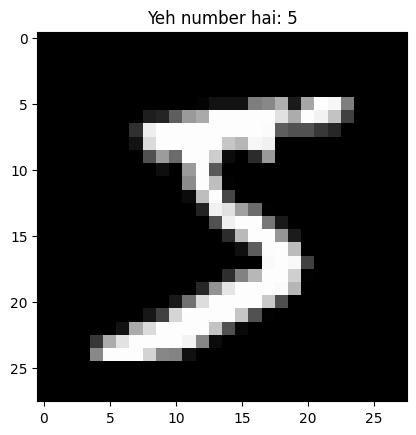

In [ ]:
image, label = train_data[0]
plt.imshow(image.squeeze(), cmap='gray')
plt.title(f"Yeh number hai: {label}")
plt.show()

In [ ]:
train_loader = torch.utils.data.DataLoader(train_data,
                                          batch_size=64,
                                          shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data,
                                         batch_size=64,
                                         shuffle=False)
print("Done!")

Done!


In [ ]:
class DigitRecognizer(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),           # Image → 784 numbers
            nn.Linear(784, 128),    # 784 → 128 neurons
            nn.ReLU(),              # Activation function
            nn.Linear(128, 64),     # 128 → 64 neurons
            nn.ReLU(),
            nn.Linear(64, 10)       # 64 → 10 outputs (0-9)
        )

    def forward(self, x):
        return self.layers(x)

model = DigitRecognizer()
print(model)

DigitRecognizer(
  (layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
print("Ready to train!")

Ready to train!


In [ ]:
epochs = 5
for epoch in range(epochs):
    total_loss = 0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} — Loss: {total_loss/len(train_loader):.4f}")

Epoch 1/5 — Loss: 0.3462
Epoch 2/5 — Loss: 0.1417
Epoch 3/5 — Loss: 0.0975
Epoch 4/5 — Loss: 0.0744
Epoch 5/5 — Loss: 0.0592


In [ ]:
correct = 0
total = 0

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Model ki Accuracy: {accuracy:.2f}%")

Model ki Accuracy: 97.33%


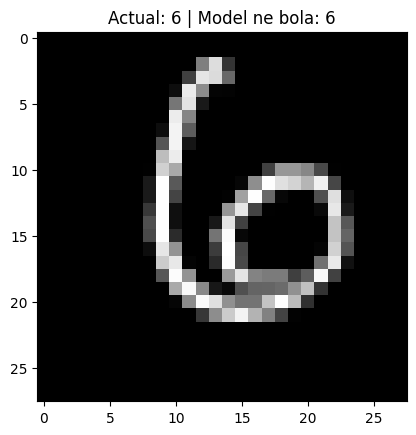

In [ ]:
image, label = test_data[100]

model.eval()
with torch.no_grad():
    output = model(image.unsqueeze(0))
    _, predicted = torch.max(output, 1)

plt.imshow(image.squeeze(), cmap='gray')
plt.title(f"Actual: {label} | Model ne bola: {predicted.item()}")
plt.show()